In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
df = pd.read_csv("../Data/processed/student_success_modeling_data.csv")

X = df.drop("success", axis=1)
y = df["success"]

print(X.shape)
print(y.shape)

(32593, 21)
(32593,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.30),
    Dense(32, activation="relu"),
    Dropout(0.20),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

c:\Users\kkell\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
571/571 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6877 - loss: 0.5918 - val_accuracy: 0.7686 - val_loss: 0.5093
Epoch 2/50
571/571 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7421 - loss: 0.5315 - val_accuracy: 0.7773 - val_loss: 0.4807
Epoch 3/50
571/571 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7586 - loss: 0.5062 - val_accuracy: 0.7835 - val_loss: 0.4698
Epoch 4/50
571/571 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7618 - loss: 0.4977 - val_accuracy: 0.7857 - val_loss: 0.4645
Epoch 5/50
571/571 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7678 - loss: 0.4922 - val_accuracy: 0.7898 - val_loss: 0.4657
Epoch 6/50
571/571 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7698 - loss: 0.4848 - val_accuracy: 0.7918 - val_loss: 0.4557
Epoch 7/50
571/571 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7717 - loss: 0.4834 - val_accuracy: 0.7901 - val_loss: 0.4623
Epoch 8/50
571/571 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7730 - loss: 0.4778 - val_accuracy: 0.

In [7]:
y_prob = model.predict(X_test_scaled).ravel()
y_pred = (y_prob >= 0.5).astype(int)

306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [8]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Neural Network Results")
print("----------------------")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Neural Network Results
----------------------
Accuracy:  0.7772
Precision: 0.7319
Recall:    0.8332
F1 Score:  0.7793
ROC-AUC:   0.8571


In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.73      0.78      5162
           1       0.73      0.83      0.78      4616

    accuracy                           0.78      9778
   macro avg       0.78      0.78      0.78      9778
weighted avg       0.78      0.78      0.78      9778



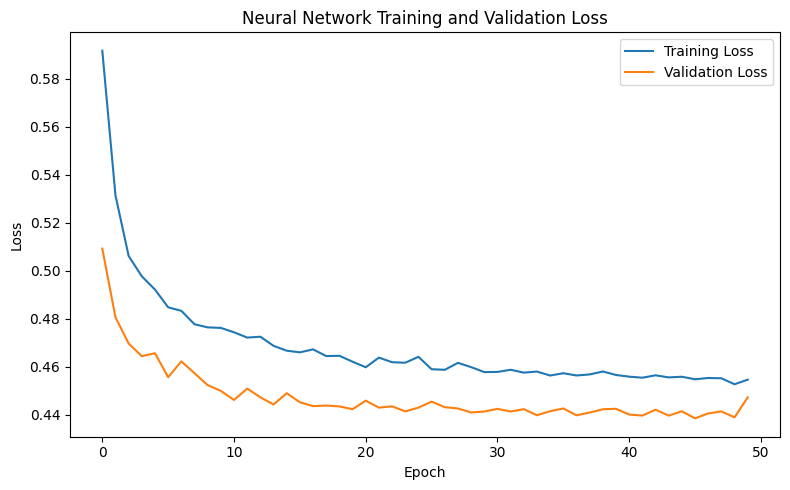

In [10]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Neural Network Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../Figures/neural_network_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Neural Network"
    ],
    "ROC_AUC": [
        0.8264,
        0.8202,
        0.8614,
        roc_auc
    ]
})

comparison.sort_values("ROC_AUC", ascending=False)

,Model,ROC_AUC
2,XGBoost,0.861400
3,Neural Network,0.857119
0,Logistic Regression,0.826400
1,Random Forest,0.820200
